<a href="https://colab.research.google.com/github/liujia-lst/ds2026-KneeCoT-IDTBD-group4/blob/main/code/kneecot-h5-pipeline-vlm/VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VLM Evaluation Pipeline — KneeCoT

Evaluates Vision-Language Models on knee MRI yes/no QA pairs.

| | |
|---|---|
| **Models** | Qwen2-VL (primary), minicpm-v (toggle on/off) |
| **RQ2** | Does CoT help VLM? |
| **RQ3** | When is visual info actually needed? |

> **Quick start:** Run all cells top to bottom. Only Qwen2-VL is enabled by default.
> To compare models, flip `enabled: False → True` in Cell 1 (Configuration).

## 0. Install Dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ollama nibabel pillow pandas matplotlib opencv-python-headless -q

## 1. Configuration

> - Flip `enabled` to `True` / `False` to include/exclude a model
> - Change `N_EVAL` to run on fewer cases during testing (e.g. `N_EVAL = 20`)
> - Update `ROOT` if your data is in a different folder

In [3]:
import os, json, re, random, base64, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from PIL import Image
import ollama

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = r"/content/drive/MyDrive/DS/KneeCoT"
TRAIN_ANN    = os.path.join(ROOT, "annotations", "train_data")
TEST_ANN    = os.path.join(ROOT, "annotations", "test_data")
TRAIN_NII    = os.path.join(ROOT, "train_data")
TEST_NII    = os.path.join(ROOT, "test_data")
TRAIN_SLC    = os.path.join(ROOT, "slices", "train")
TEST_SLC    = os.path.join(ROOT, "slices", "test")
EVAL_PATH = os.path.join(ROOT, "eval_set.json")

#EVAL_PATH   = os.path.join(ROOT, "eval_dataset.json")
RESULTS_DIR = os.path.join(ROOT, "vlm_results")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(TRAIN_SLC,    exist_ok=True)

# ── Model toggle ──────────────────────────────────────────────────────────────
# Set enabled=True  → model runs
# Set enabled=False → model is skipped
#
# WHY Qwen2-VL is the only one enabled by default:
#   LLaVA and BakLLaVA have English-only base models (Vicuna-7B / Mistral-7B).
#   On Chinese CoT, they fail to reach the 【答案】 tag → parsed as UNCLEAR.
#   This makes CoT accuracy look like 20% when it's really a language/format bug.
#   Qwen2-VL shares the same family as the text-line Qwen2.5-7B → clean RQ2 comparison.
MODELS = {
    "qwen2.5vl": {"enabled": True,  "note": "PRIMARY — strong Chinese, same family as Qwen2.5-7B text line"},
    "minicpm-v":    {"enabled": True, "note": "Secondary "},
}

# ── Eval size ─────────────────────────────────────────────────────────────────
# Set to None to use all available cases (up to 300 balanced)
# Set to a small number (e.g. 20) for a quick test run
N_EVAL = 50   # None = full 300-case balanced set

# ─────────────────────────────────────────────────────────────────────────────
ACTIVE_MODELS = [m for m, cfg in MODELS.items() if cfg["enabled"]]

print("=" * 55)
print("  ENABLED:")
for m in ACTIVE_MODELS:
    print(f"    ✓  {m}")
print("  DISABLED:")
for m, cfg in MODELS.items():
    if not cfg["enabled"]:
        print(f"    ✗  {m}  ({cfg['note']})")
print("=" * 55)
print(f"  Eval size: {N_EVAL if N_EVAL else 'up to 300 (balanced)'}")
print(f"  Results → {RESULTS_DIR}")


  ENABLED:
    ✓  qwen2.5vl
    ✓  minicpm-v
  DISABLED:
  Eval size: 50
  Results → /content/drive/MyDrive/DS/KneeCoT/vlm_results


## 2. Chinese Prompts + Answer Parser

Both prompts end with `【答案】` so the parser always knows exactly where to look for Yes/No.

| Prompt | Description |
|---|---|
| **DA** | Direct Answer — no reasoning, just the answer |
| **CoT** | 4-step structured reasoning in Chinese, then answer |

> **Why Chinese prompts?** The dataset is Chinese. English prompts cause models to mix
> languages in long CoT generations, making the 【答案】 tag unreachable → UNCLEAR.

In [4]:
# ── Prompts ───────────────────────────────────────────────────────────────────



VLM_PROMPTS = {

    "DA":  """你是一位资深骨骼肌肉放射科医生。下面给出一组膝关节 MR 图像和一个相关问题。
请根据图像直接回答问题，不要写出推理过程。
- 若为是非类问题：请在【答案】后只回答 Yes 或 No。
- 若为推理类问题：请在【答案】后给出明确结论及简要依据。
【问题】{question}
【答案】""",

    "CoT": """你是一位资深骨骼肌肉放射科医生。请根据下面给出的膝关节 MR 图像，按以下四个步骤进行系统推理，然后回答问题。

步骤一 系统性观察（Systematic Observation）
系统性地观察所给的 MR 图像，按解剖部位（半月板、韧带、骨与软骨、关节腔与滑膜、其他结构如脂肪垫与软组织）逐项描述你在图像中观察到的关键征象，记录信号、形态与连续性。

步骤二 解读与核对（Interpretation and Verification）
对每条征象判断正常还是异常，说明该改变通常提示什么（如 T2WI 高信号提示水肿/损伤），核对前后一致性。

步骤三 解剖结构分析（Anatomical Structure Analysis）
3.1 半月板：形态是否完整、高信号是否达关节面、损伤程度。
3.2 韧带：前/后交叉韧带、内/外侧副韧带的连续性与信号。
3.3 骨与软骨：骨髓信号（水肿/挫伤）、关节面软骨是否光整。
3.4 关节腔与滑膜：有无积液、滑膜情况。
3.5 其他结构：髌下脂肪垫、关节周围软组织。

步骤四 诊断推理与核对（Diagnostic Reasoning and Verification）
综合分析推导结论；如适用简要排除主要鉴别诊断；自检结论是否由证据支持。

最后在【答案】后给出明确回答：是非类答 Yes/No；推理类给结论及依据。
【问题】{question}
请依次完成步骤一至步骤四，最后给出【答案】""",

"DA_findings": """你是一位资深骨骼肌肉放射科医生。下面给出一组膝关节 MR 图像、对应的 MR 表现文字和一个相关问题。
请结合图像与 MR 表现直接回答问题，不要写出推理过程。
- 若为是非类问题：请在【答案】后只回答 Yes 或 No。
- 若为推理类问题：请在【答案】后给出明确结论及简要依据。
【MR 表现】{findings}
【问题】{question}
【答案】""" ,

"CoT_findings":"""你是一位资深骨骼肌肉放射科医生。请根据下面给出的膝关节 MR 图像及其对应的 MR 表现文字，按以下四个步骤进行系统推理，然后回答问题。

步骤一 系统性观察（Systematic Observation）
系统性地观察所给的 MR 图像，并对照所提供的 MR 表现文字，按解剖部位（半月板、韧带、骨与软骨、关节腔与滑膜、其他结构如脂肪垫与软组织）逐项梳理关键征象，记录信号、形态与连续性。

步骤二 解读与核对（Interpretation and Verification）
对每条征象判断正常还是异常，说明该改变通常提示什么（如 T2WI 高信号提示水肿/损伤），核对前后一致性。

步骤三 解剖结构分析（Anatomical Structure Analysis）
3.1 半月板：形态是否完整、高信号是否达关节面、损伤程度。
3.2 韧带：前/后交叉韧带、内/外侧副韧带的连续性与信号。
3.3 骨与软骨：骨髓信号（水肿/挫伤）、关节面软骨是否光整。
3.4 关节腔与滑膜：有无积液、滑膜情况。
3.5 其他结构：髌下脂肪垫、关节周围软组织。

步骤四 诊断推理与核对（Diagnostic Reasoning and Verification）
综合分析推导结论；如适用简要排除主要鉴别诊断；自检结论是否由证据支持。

最后在【答案】后给出明确回答：是非类答 Yes/No；推理类给结论及依据。
【MR 表现】{findings}
【问题】{question}
请依次完成步骤一至步骤四，最后给出【答案】。  """

}


# ── Answer parser ─────────────────────────────────────────────────────────────
import re

ANSWER_MARKER = "【答案】"

def parse_yes_no(raw_output):
    """Shared parser for both text and VLM pipelines.
    Returns 'Yes', 'No', or None.
    """
    if not raw_output or not raw_output.strip():
        return None

    text = raw_output.strip()

    # Priority 1: after 【答案】 marker
    if ANSWER_MARKER in text:
        text = text.split(ANSWER_MARKER)[-1].strip()

    # Priority 2: English Yes/No
    m = re.search(r"\b(yes|no)\b", text, re.IGNORECASE)
    if m:
        return m.group(1).capitalize()

    # Priority 3: Chinese 是/否
    last_yes = text.rfind("是")
    last_no  = text.rfind("否")
    if last_yes == -1 and last_no == -1:
        return None
    return "Yes" if last_yes > last_no else "No"



## 3. Extract PNG Slices from .nii Files

**Key improvements over original:**
- Auto-detects the sagittal axis (largest dimension) instead of assuming axis=2
- Uses **2 center-biased slices** — ACL and PCL are in the *central* slices, not the edges
- `begin/middle/end` was biased toward peripheral tissue with low diagnostic value

> **Paper Limitation:** Restricted to 2 slices per scan. Peripheral structures may be missed.
> The visual contribution measured here is a **lower bound**.

In [ ]:
def extract_slices(nii_path, output_dir, case_id):
    """
    Extract n_slices PNG images from a .nii file.
    - Sagittal axis = largest dimension (auto-detected, not assumed)
    - Center-biased: samples from the middle half of the volume
      because ACL/PCL are in central slices, not the periphery
    """
    img  = nib.load(nii_path)
    data = img.get_fdata()

    sag_axis = int(np.argmax(data.shape))   # largest axis = sagittal
    D = data.shape[sag_axis]

    # 5 indices spread across the central half of the volume
    indices = sorted(set([D//3, D//2]))

    os.makedirs(output_dir, exist_ok=True)
    for i, idx in enumerate(indices):
        sl    = np.take(data, idx, axis=sag_axis)
        p1, p99 = np.percentile(sl, 1), np.percentile(sl, 99)
        sl_norm = np.clip((sl - p1) / (p99 - p1 + 1e-8) * 255, 0, 255).astype(np.uint8)
        Image.fromarray(sl_norm).convert("RGB").save(
            os.path.join(output_dir, f"{case_id}_slice{i}.png"))


# ── Run extraction ────────────────────────────────────────────────────────────
def run_slice_extraction(src_nii_dir, out_slc_dir, split_name):
    nii_files = [f for f in os.listdir(src_nii_dir) if f.endswith(".nii")]
    print(f"\n[{split_name}] Found {len(nii_files)} .nii files — extracting 5 center-biased slices each...")

    errors = []
    for fname in nii_files:
        case_id = fname.replace(".nii", "")
        try:
            extract_slices(os.path.join(src_nii_dir, fname), out_slc_dir, case_id)
            print(f"  {case_id}", end="  ")
        except Exception as e:
            print(f"{case_id} ERROR: {e}")
            errors.append(case_id)

    total = len([f for f in os.listdir(out_slc_dir) if f.endswith(".png")])
    print(f"\n[{split_name}] Done! PNGs: {total}   Errors: {len(errors)}")
    if errors:
        print(f"[{split_name}] Failed: {errors}")

# run on both splits
os.makedirs(TRAIN_SLC, exist_ok=True)
os.makedirs(TEST_SLC, exist_ok=True)

run_slice_extraction(TRAIN_NII, TRAIN_SLC, "TRAIN")
run_slice_extraction(TEST_NII, TEST_SLC, "TEST")


[TRAIN] Found 62 .nii files — extracting 5 center-biased slices each...
  GJB0000003T_02    GJB0000001T_01    GJB0000002T_02    GJB0000003T_01    GJB0000002T_01    GJB0000004T_01    GJB0000005T_01    GJB0000006T_01    GJB0000006T_02    GJB0000007T_01    GJB0000008T_01    GJB0000009T_01    GJB0000010T_01    GJB0000011T_01    GJB0000012T_01    GJB0000012T_02    GJB0000012T_03    GJB0000013T_01    GJB0000014T_01    GJB0000014T_02    GJB0000014T_03    GJB0000015T_01    GJB0000016T_01  GJB0000017T_01 ERROR: Expected 155713536 bytes, got 33554080 bytes from /content/drive/MyDrive/DS/KneeCoT/train_data/GJB0000017T_01.nii
 - could the file be damaged?
  GJB0000017T_02    GJB0000018T_01    GJB0000019T_01    GJB0000020T_01    GJB0000021T_01    GJB0000022T_01    GJB0000023T_01    GJB0000025T_01    GJB0000024T_01    GJB0000026T_01    GJB0000027T_01    GJB0000028T_01    GJB0000029T_01    GJB0000029T_02    GJB0000030T_01    GJB0000031T_01    GJB0000032T_01    GJB0000033T_01    GJB0000034T_01    GJB

#### Image enhancement

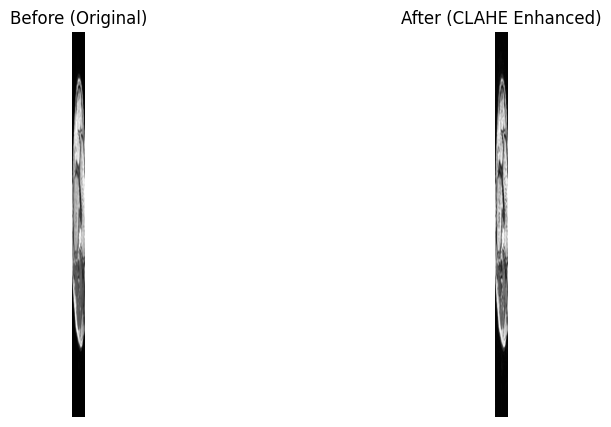

In [8]:
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob

def load_enhanced_slice(path):
    img = np.array(Image.open(path).convert("L"))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img)
    return Image.fromarray(enhanced).convert("RGB")

# Find a sample image and display before/after
sample_paths = glob.glob('/content/drive/MyDrive/DS/KneeCoT/slices/*/*.png')
if sample_paths:
    sample_path = sample_paths[0]
    original = Image.open(sample_path).convert("RGB")
    enhanced = load_enhanced_slice(sample_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original)
    axes[0].set_title("Before (Original)")
    axes[0].axis('off')

    axes[1].imshow(enhanced)
    axes[1].set_title("After (CLAHE Enhanced)")
    axes[1].axis('off')

    plt.show()
else:
    print("No sample images found to display.")


## 4. Build Evaluation Dataset


In [17]:
import os, json, re, glob, random

YESNO_MARKERS = ["是否", "有无", "是不是", "有没有", "能否"]
EXCLUDE_JOINTS = ["踝关节", "肩关节", "髋关节", "腕关节", "肘关节"]

def is_true_yesno(qa):
    if qa.get("type") != "yes_no":
        return False
    answer = qa.get("answer", "").strip()
    if not (answer.startswith("Yes") or answer.startswith("No")):
        return False
    question = qa.get("question", "")
    if not any(m in question for m in YESNO_MARKERS):
        return False
    if any(j in question for j in EXCLUDE_JOINTS):
        return False
    return True

def is_inference(qa):
    if qa.get("type") != "inference":
        return False
    if any(j in qa.get("question", "") for j in EXCLUDE_JOINTS):
        return False
    return True

def norm(x):
    return str(x).strip().replace(".json", "")

def find_nii(case_name, case_id, nii_dir):
    candidates = [
        case_name,
        case_id,
        f"{case_name}_01",
        f"{case_id}_01",
    ]
    for c in dict.fromkeys(candidates):
        p = os.path.join(nii_dir, f"{c}.nii")
        if os.path.exists(p):
            return p
    patterns = [
        os.path.join(nii_dir, f"{case_name}*.nii"),
        os.path.join(nii_dir, f"{case_id}*.nii"),
    ]
    for pat in patterns:
        hits = sorted(glob.glob(pat))
        if hits:
            return hits[0]
    return None

def build_vlm_eval_set(ann_dirs, nii_dirs, eval_out_path, n_eval=None, seed=42):
    all_cases = []
    miss_nii = {"train": 0, "test": 0}

    for split, ann_dir in ann_dirs:
        if not os.path.exists(ann_dir):
            print(f"Missing annotation dir: {ann_dir}")
            continue

        nii_dir = nii_dirs[split]
        json_files = sorted(glob.glob(os.path.join(ann_dir, "**", "*.json"), recursive=True))
        print(f"{split}: found {len(json_files)} annotation json files")

        for json_path in json_files:
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            # Knee-only filter — matches LLM preprocessing.is_knee_only_case()
            method = data.get("检查方法", "")
            if "膝关节" not in method or "肩关节" in method:
                continue

            case_name = norm(os.path.splitext(os.path.basename(json_path))[0])
            case_id = norm(data.get("顺序编号", case_name))
            findings = data.get("MR表现", "")
            qa_pairs = data.get("问答数据", {}).get("qa_pairs", [])

            nii_path = find_nii(case_name, case_id, nii_dir)
            if nii_path is None:
                miss_nii[split] += 1
                continue

            for qa in qa_pairs:
                if is_true_yesno(qa):
                    raw_answer = qa["answer"].strip()
                    ground_truth = "Yes" if raw_answer.startswith("Yes") else "No"
                    all_cases.append({
                        "case_id": case_id,
                        "case_name": case_name,
                        "split": split,
                        "nii_path": nii_path,
                        "findings": findings,
                        "question": qa["question"],
                        "ground_truth": ground_truth,
                        "full_answer": raw_answer,
                        "qtype": "yes_no",
                    })
                elif is_inference(qa):
                    all_cases.append({
                        "case_id": case_id,
                        "case_name": case_name,
                        "split": split,
                        "nii_path": nii_path,
                        "findings": findings,
                        "question": qa["question"],
                        "ground_truth": qa["answer"].strip(),
                        "full_answer": qa["answer"].strip(),
                        "qtype": "inference",
                    })

    yesno_pool = [c for c in all_cases if c["qtype"] == "yes_no"]
    infer_pool = [c for c in all_cases if c["qtype"] == "inference"]

    print(f"Missing NII-match cases | train={miss_nii['train']} test={miss_nii['test']}")
    print(f"Total case IDs loaded   : {len(set(c['case_id'] for c in all_cases))}")
    print(f"Total QA pairs loaded   : {len(all_cases)} (Yes/No: {len(yesno_pool)}, Inference: {len(infer_pool)})")

    if len(all_cases) == 0:
        raise ValueError("No cases loaded. Check annotation json layout and .nii naming.")

    if n_eval is None:
        sampled = all_cases
    else:
        random.seed(seed)

        # Per-case: at most one Yes and one No per case_id (paper requirement)
        yes_by_case = {}
        no_by_case = {}
        for c in yesno_pool:
            if c["ground_truth"] == "Yes" and c["case_id"] not in yes_by_case:
                yes_by_case[c["case_id"]] = c
            elif c["ground_truth"] == "No" and c["case_id"] not in no_by_case:
                no_by_case[c["case_id"]] = c

        yes_pool = list(yes_by_case.values())
        no_pool = list(no_by_case.values())

        # Balanced sampling: 25 Yes + 25 No = 50 yes/no
        half = n_eval // 2 if n_eval % 2 == 0 else (n_eval - 1) // 2
        sampled_yesno = (
            random.sample(yes_pool, min(half, len(yes_pool))) +
            random.sample(no_pool, min(half, len(no_pool)))
        )

        # Inference questions: all available
        sampled_infer = infer_pool[:]

        sampled = sampled_yesno + sampled_infer
        random.shuffle(sampled)

    print(f"\nEvaluation set size : {len(sampled)}")
    print(f"  - Yes/No QA pairs : {len([c for c in sampled if c['qtype'] == 'yes_no'])}")
    print(f"  - Inference pairs : {len([c for c in sampled if c['qtype'] == 'inference'])}")

    with open(eval_out_path, "w", encoding="utf-8") as f:
        json.dump(sampled, f, ensure_ascii=False, indent=2)
    print(f"\nEvaluation set saved to: {eval_out_path}")
    return sampled

# --- Execution ---
ANN_DIRS = [
    ("test", os.path.join(ROOT, "annotations", "test_data")),
    ("train", os.path.join(ROOT, "annotations", "train_data")),
]
NII_DIRS = {
    "test": os.path.join(ROOT, "test_data"),
    "train": os.path.join(ROOT, "train_data"),
}

# Build eval set with same seed=42 and stratified sampling as LLM pipeline.
# LLM uses build_eval_set() with seed=42, VLM uses build_vlm_eval_set() with seed=42.
# Both apply the same knee-only filtering, per-case dedup, and 25 Yes + 25 No balance.
# This guarantees matched (case_id, question_id) pairs across pipelines.
# Seed 42 matches LLM's preprocessing.build_eval_set() for matched comparison.
sampled_eval_set = build_vlm_eval_set(ANN_DIRS, NII_DIRS, EVAL_PATH, n_eval=N_EVAL)


test: found 10 annotation json files
train: found 50 annotation json files
Missing NII-match cases | train=0 test=0
Total case IDs loaded   : 60
Total QA pairs loaded   : 1267 (Yes/No: 826, Inference: 441)

Evaluation set size : 50
  - Yes/No QA pairs : 25
  - Inference pairs : 25

Evaluation set saved to: /content/drive/MyDrive/DS/KneeCoT/eval_set.json


In [ ]:
%%writefile /content/build_eval_set.py
import os
import json
import glob
import random

# Keywords used to identify Yes/No questions
YES_NO_MARKERS = ["是否", "有无", "是不是", "有没有", "能否"]

# Joints to exclude from our knee-focused dataset
EXCLUDE_JOINTS = ["踝关节", "肩关节", "髋关节", "腕关节", "肘关节"]

def is_valid_yes_no_question(qa_pair):
    """Checks if a given question-answer pair is a valid Yes/No question for the knee joint."""
    if qa_pair.get("type") != "yes_no":
        return False

    answer = qa_pair.get("answer", "").strip()
    if not (answer.startswith("Yes") or answer.startswith("No")):
        return False

    question = qa_pair.get("question", "")

    # Ensure it contains a Yes/No marker
    if not any(marker in question for marker in YES_NO_MARKERS):
        return False

    # Exclude questions about other joints
    if any(joint in question for joint in EXCLUDE_JOINTS):
        return False

    return True

def is_valid_inference_question(qa_pair):
    """Checks if a given question is a valid open-ended inference question for the knee."""
    if qa_pair.get("type") != "inference":
        return False

    question = qa_pair.get("question", "")
    if any(joint in question for joint in EXCLUDE_JOINTS):
        return False

    return True

def clean_filename(name):
    """Removes the file extension and leading/trailing whitespace from a filename."""
    return str(name).strip().replace(".json", "")

def locate_nifti_image(case_name, case_id, nii_directory):
    """Attempts to locate the corresponding .nii image file for a given case."""
    # Try exact matches first
    exact_candidates = [
        case_name,
        case_id,
        f"{case_name}_01",
        f"{case_id}_01",
    ]

    for candidate in dict.fromkeys(exact_candidates):
        path = os.path.join(nii_directory, f"{candidate}.nii")
        if os.path.exists(path):
            return path

    # Try pattern matching as a fallback
    patterns = [
        os.path.join(nii_directory, f"{case_name}*.nii"),
        os.path.join(nii_directory, f"{case_id}*.nii"),
    ]

    for pattern in patterns:
        matching_files = sorted(glob.glob(pattern))
        if matching_files:
            return matching_files[0]

    return None

def create_evaluation_dataset(annotation_dirs, nii_dirs, output_filepath, num_samples=None, random_seed=42):
    """
    Parses annotations and NIfTI images to build a balanced evaluation dataset.
    """
    all_cases = []
    missing_images = {"train": 0, "test": 0}

    # Process both train and test splits
    for split, ann_dir in annotation_dirs:
        if not os.path.exists(ann_dir):
            print(f"⚠️ Warning: Missing annotation directory: {ann_dir}")
            continue

        nii_dir = nii_dirs[split]
        json_files = sorted(glob.glob(os.path.join(ann_dir, "**", "*.json"), recursive=True))
        print(f"[{split.upper()}] Found {len(json_files)} annotation files.")

        for json_path in json_files:
            with open(json_path, "r", encoding="utf-8") as file:
                data = json.load(file)

            # Extract case identifiers and medical findings
            case_name = clean_filename(os.path.basename(json_path))
            case_id = clean_filename(data.get("顺序编号", case_name))
            medical_findings = data.get("MR表现", "")
            qa_pairs = data.get("问答数据", {}).get("qa_pairs", [])

            # Match with image
            nii_path = locate_nifti_image(case_name, case_id, nii_dir)
            if not nii_path:
                missing_images[split] += 1
                continue

            # Filter and categorize questions
            for qa in qa_pairs:
                if is_valid_yes_no_question(qa):
                    raw_answer = qa["answer"].strip()
                    ground_truth = "Yes" if raw_answer.startswith("Yes") else "No"
                    all_cases.append({
                        "case_id": case_id,
                        "case_name": case_name,
                        "split": split,
                        "nii_path": nii_path,
                        "findings": medical_findings,
                        "question": qa["question"],
                        "ground_truth": ground_truth,
                        "full_answer": raw_answer,
                        "qtype": "yes_no",
                    })
                elif is_valid_inference_question(qa):
                    all_cases.append({
                        "case_id": case_id,
                        "case_name": case_name,
                        "split": split,
                        "nii_path": nii_path,
                        "findings": medical_findings,
                        "question": qa["question"],
                        "ground_truth": qa["answer"].strip(),
                        "full_answer": qa["answer"].strip(),
                        "qtype": "inference",
                    })

    yes_no_questions = [c for c in all_cases if c["qtype"] == "yes_no"]
    inference_questions = [c for c in all_cases if c["qtype"] == "inference"]

    print(f"\n📊 Dataset Loading Summary:")
    print(f"  - Missing NII matching cases: Train={missing_images['train']}, Test={missing_images['test']}")
    print(f"  - Total Unique Case IDs: {len(set(c['case_id'] for c in all_cases))}")
    print(f"  - Total QA Pairs Loaded: {len(all_cases)} (Yes/No: {len(yes_no_questions)}, Inference: {len(inference_questions)})")

    if not all_cases:
        raise ValueError("❌ No valid cases loaded. Please check the annotation directory and NIfTI file naming conventions.")

    # Sampling logic to balance the dataset
    if num_samples is None:
        final_dataset = all_cases
    else:
        random.seed(random_seed)
        yes_pool = [c for c in yes_no_questions if c["ground_truth"] == "Yes"]
        no_pool = [c for c in yes_no_questions if c["ground_truth"] == "No"]

        # Aim to balance Yes and No questions equally, taking half the target samples
        half_target = num_samples // 2
        yes_no_target = half_target // 2

        sampled_yes_no = (
            random.sample(yes_pool, min(yes_no_target, len(yes_pool))) +
            random.sample(no_pool, min(half_target - yes_no_target, len(no_pool)))
        )

        # Fill the remaining requested size with inference questions
        remaining = num_samples - len(sampled_yes_no)
        sampled_inference = random.sample(inference_questions, min(remaining, len(inference_questions)))

        final_dataset = sampled_yes_no + sampled_inference
        random.shuffle(final_dataset)

    print(f"\n📁 Final Evaluation Set Size: {len(final_dataset)}")
    print(f"  - Yes/No QA Pairs : {len([c for c in final_dataset if c['qtype'] == 'yes_no'])}")
    print(f"  - Inference Pairs : {len([c for c in final_dataset if c['qtype'] == 'inference'])}")

    # Save to disk
    with open(output_filepath, "w", encoding="utf-8") as output_file:
        json.dump(final_dataset, output_file, ensure_ascii=False, indent=2)

    print(f"✅ Evaluation set successfully saved to: {output_filepath}")
    return final_dataset


Overwriting /content/build_eval_set.py


## 5. Helper Functions

In [9]:
def calculate_metrics(results):
    total = len(results)
    if total == 0:
        return {}

    unclear = sum(1 for r in results if r["prediction"] in ["UNCLEAR", None])
    parsed = [r for r in results if r["prediction"] not in ["UNCLEAR", None]]

    tp = sum(1 for r in parsed if r["prediction"] == "Yes" and r["ground_truth"] == "Yes")
    tn = sum(1 for r in parsed if r["prediction"] == "No" and r["ground_truth"] == "No")
    fp = sum(1 for r in parsed if r["prediction"] == "Yes" and r["ground_truth"] == "No")
    fn = sum(1 for r in parsed if r["prediction"] == "No" and r["ground_truth"] == "Yes")

    yes_acc = tp / (tp + fn) if (tp + fn) > 0 else 0
    no_acc = tn / (tn + fp) if (tn + fp) > 0 else 0
    correct = tp + tn
    accuracy = correct / total
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "yes_acc": round(yes_acc, 4),
        "no_acc": round(no_acc, 4),
        "correct": correct,
        "unclear": unclear,
        "unclear_pct": round(unclear / total * 100, 1),
        "total": total,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def evaluate_vlm_batch(cases, model, prompt_template, prompt_type,text_only=False):
    import glob, os, io, base64
    results, failed = [], []

    print(f"{'─'*55}")
    print(f" Model: {model} Prompt: {prompt_type}")
    print(f"{'─'*55}")

    for i, case in enumerate(cases):
        case_id = case["case_id"]
        gt = case["ground_truth"]
        question = case["question"]

        try:
            slc_dir = TRAIN_SLC if case.get("split") == "train" else TEST_SLC
            slice_paths = case.get("slice_paths", [])
            nii_path = case.get("nii_path")
            base_nii = os.path.basename(nii_path).replace(".nii", "") if nii_path else case_id

            # Attempt to find the images
            if not slice_paths:
                slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{base_nii}*.png")))
                if not slice_paths:
                    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{case.get('case_name', case_id)}*.png")))
                if not slice_paths:
                    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{case_id}*.png")))

            # If still not found, auto-extract on the fly!
            if not slice_paths and nii_path and os.path.exists(nii_path):
                # extract_slices is defined in cell c33058
                extract_slices(nii_path, slc_dir, base_nii)
                slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{base_nii}*.png")))

            if not slice_paths:
                raise ValueError(f"No extracted slice images found and auto-extract failed.")

            images_b64 = []
            for img_path in slice_paths:
                enhanced = load_enhanced_slice(img_path)
                buf = io.BytesIO()
                enhanced.save(buf, format="PNG")
                images_b64.append(base64.b64encode(buf.getvalue()).decode())

            prompt = prompt_template.format(
                question=question,
                findings=case.get("findings", "")
            )

            response = ollama.chat(
                model=model,
                messages=[{
                    "role": "user",
                    "content": prompt,
                    **({"images": images_b64} if not text_only else {})
                }],
                options={"temperature": 0.0, "num_predict": 2400, "num_ctx": 4096}
            )

            raw = response["message"]["content"]
            pred = parse_yes_no(raw)
            pred_label = pred if pred in ["Yes", "No"] else "UNCLEAR"
            correct = (pred_label == gt)

            results.append({
                "case_id": case_id,
                "question": question,
                "qtype": case.get("qtype", "yes_no"),
                "ground_truth": gt,
                "gt_answer": case.get("gt_answer", gt),
                "prediction": pred_label,
                "correct": correct,
                "prompt_type": prompt_type,
                "model": model,
                "raw_response": raw,
                "findings": case.get("findings", ""),
                "slice_paths": slice_paths,
            })

            icon = "✓" if correct else ("?" if pred_label == "UNCLEAR" else "✗")
            print(f" {i+1:>3}/{len(cases)} {icon} {case_id} GT={gt:<3} Pred={pred_label}")

        except Exception as e:
            print(f" {i+1:>3}/{len(cases)} ERR {case_id}: {str(e)[:60]}")
            failed.append(case_id)

    m = calculate_metrics(results)
    print(
        f"Acc={m.get('accuracy',0):.3f} F1={m.get('f1',0):.3f} "
        f"UNCLEAR={m.get('unclear',0)}/{m.get('total',1)} ({m.get('unclear_pct',0)}%) "
        f"Errors={len(failed)}"
    )
    if m.get("unclear_pct", 0) > 15 and prompt_type == "CoT":
        print(" ⚠ High UNCLEAR under CoT → likely language/format failure, not reasoning failure")

    return results

def parse_inference_answer(raw_output):
    """
    Extracts the text answer for inference questions.
    Looks for the 【答案】 marker and returns everything after it.
    """
    if not raw_output:
        return ""
    if "【答案】" in raw_output:
        return raw_output.split("【答案】")[-1].strip()
    return raw_output.strip()

def evaluate_inference_batch(cases, model, prompt_template, prompt_type, text_only=False):
    import glob, os, io, base64
    results, failed = [], []

    print(f"\n{'─'*55}")
    print(f" Model: {model} | Prompt: {prompt_type} | Type: Inference")
    print(f"{'─'*55}")

    for i, case in enumerate(cases):
        case_id = case["case_id"]
        gt = case["ground_truth"]
        question = case["question"]

        try:
            slc_dir = TRAIN_SLC if case.get("split") == "train" else TEST_SLC
            slice_paths = case.get("slice_paths", [])
            nii_path = case.get("nii_path")
            base_nii = os.path.basename(nii_path).replace(".nii", "") if nii_path else case_id

            # Attempt to find the images
            if not slice_paths:
                slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{base_nii}*.png")))
                if not slice_paths:
                    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{case.get('case_name', case_id)}*.png")))
                if not slice_paths:
                    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{case_id}*.png")))

            # If still not found, auto-extract on the fly!
            if not slice_paths and nii_path and os.path.exists(nii_path):
                extract_slices(nii_path, slc_dir, base_nii)
                slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{base_nii}*.png")))

            if not slice_paths:
                raise ValueError(f"No extracted slice images found and auto-extract failed.")

            images_b64 = []
            for img_path in slice_paths:
                enhanced = load_enhanced_slice(img_path)
                buf = io.BytesIO()
                enhanced.save(buf, format="PNG")
                images_b64.append(base64.b64encode(buf.getvalue()).decode())

            prompt = prompt_template.format(
                question=question,
                findings=case.get("findings", "")
            )

            response = ollama.chat(
                model=model,
                messages=[{
                    "role": "user",
                    "content": prompt,
                    **({"images": images_b64} if not text_only else {})
                }],
                options={"temperature": 0.0, "num_predict": 2400, "num_ctx": 4096}
            )

            raw = response["message"]["content"]
            pred_text = parse_inference_answer(raw)

            results.append({
                "case_id": case_id,
                "question": question,
                "qtype": "inference",
                "ground_truth": gt,
                "prediction": pred_text,
                "prompt_type": prompt_type,
                "model": model,
                "raw_response": raw,
                "findings": case.get("findings", ""),
                "slice_paths": slice_paths,
            })

            print(f" {i+1:>3}/{len(cases)} ✓ {case_id} processed.")

        except Exception as e:
            print(f" {i+1:>3}/{len(cases)} ERR {case_id}: {str(e)[:60]}")
            failed.append(case_id)

    print(f"\nCompleted {len(results)}/{len(cases)} inference cases. Errors: {len(failed)}")
    return results


## 6. Run Evaluation

1. Checks which models are actually available in Ollama
2. Runs DA + CoT for every enabled model
3. Saves results to JSON after each model (so progress is not lost on crash)

> To pull a model: `ollama pull qwen2-vl`

In [10]:
!apt-get install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (2,766 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [11]:
# Install the Ollama server
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [12]:
import subprocess, time
subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(5)
!ollama pull qwen2.5vl
!ollama pull minicpm-v

### Test in one case

In [ ]:
import base64, io, ollama, os, glob

test_case = sampled_eval_set[0]
images_b64 = []

# Find the corresponding slices for this case
slc_dir = TRAIN_SLC if test_case["split"] == "train" else TEST_SLC
slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{test_case['case_name']}*.png")))
if not slice_paths:
    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{test_case['case_id']}*.png")))

# Match evaluate_vlm_batch(): load the extracted slices
for p in slice_paths:
    enhanced = load_enhanced_slice(p)
    buf = io.BytesIO()
    enhanced.save(buf, format="PNG")
    images_b64.append(base64.b64encode(buf.getvalue()).decode())

# Match evaluate_vlm_batch(): include both findings and question
test_prompt = VLM_PROMPTS["CoT"].format(
    findings=test_case["findings"],
    question=test_case["question"]
)

print(f"Prompt length: {len(test_prompt)} chars")
print(f"Question: {test_case['question']}")
print("─" * 50)

response = ollama.chat(
    model="qwen2.5vl",
    messages=[{"role": "user", "content": test_prompt, "images": images_b64}],
    options={"temperature": 0.0, "num_predict": 2400, "num_ctx": 4096}
)

raw = response["message"]["content"]
pred = parse_yes_no(raw)

print(f"Response length: {len(raw)} chars")
print(f"Parsed: {pred if pred else 'None'}")
print(f"Raw output:\n{raw}")

Prompt length: 643 chars
Question: 该患者本次膝关节 MRI 检查，胫腓骨关节面骨质是否未见明显异常？
──────────────────────────────────────────────────
Response length: 1297 chars
Parsed: Yes
Raw output:
### 步骤一：系统性观察（Systematic Observation）

1. **半月板**：
   - 信号强度：T2WI 上显示内侧和外侧半月板均呈高信号。
   - 形态与连续性：内外侧半月板形态完整，无撕裂或断裂的迹象。

2. **韧带**：
   - 前交叉韧带（PCL）：在 T1WI 和 T2WI 上显示为低信号强度，形态正常且连续。
   - 后交叉韧带（ACL）：同样在 T1WI 和 T2WI 上显示为低信号强度，形态正常且连续。
   - 内侧副韧带（MCL）和外侧副韧带（LCL）：在图像上未见明显异常。

3. **骨与软骨**：
   - 骨髓信号：胫腓骨关节面的骨髓信号均匀，无水肿或挫伤迹象。
   - 关节面软骨：关节面软骨光整，未见明显的磨损、剥脱或其他损伤征象。

4. **关节腔与滑膜**：
   - 关节腔：在 T1WI 和 T2WI 上显示为低信号强度，无积液的迹象。
   - 滑膜：滑膜信号均匀，形态正常且连续。

5. **其他结构**：
   - 髌下脂肪垫：髌下脂肪垫形态完整，信号均匀。
   - 关节周围软组织：关节周围软组织未见明显异常信号或肿胀。

### 步骤二：解读与核对（Interpretation and Verification）

- 半月板：内外侧半月板形态完整且连续，高信号提示可能的轻微水肿/损伤，但无撕裂。
- 韧带：前交叉韧带和后交叉韧带形态正常且连续，未见断裂或撕裂。
- 骨与软骨：胫腓骨关节面骨髓信号均匀，关节面软骨光整，提示没有明显的骨折、挫伤或磨损。
- 关节腔与滑膜：关节腔内无积液，滑膜信号均匀，形态正常。
- 其他结构：髌下脂肪垫和关节周围软组织未见异常。

前后一致，所有观察到的征象均符合膝关节在没有明显损伤时的表现。

### 步骤三：解剖结构分析（Anatomical Structure Analysis）

1. **半月板**：


In [ ]:
import base64, io, ollama, os, glob

# Find the first inference case in the sampled_eval_set
inference_case = next((c for c in sampled_eval_set if c["qtype"] == "inference"), None)

if inference_case:
    images_b64 = []

    # Find the corresponding slices for this case
    slc_dir = TRAIN_SLC if inference_case["split"] == "train" else TEST_SLC
    slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{inference_case['case_name']}*.png")))
    if not slice_paths:
        slice_paths = sorted(glob.glob(os.path.join(slc_dir, f"{inference_case['case_id']}*.png")))

    # Load the extracted slices
    for p in slice_paths:
        enhanced = load_enhanced_slice(p)
        buf = io.BytesIO()
        enhanced.save(buf, format="PNG")
        images_b64.append(base64.b64encode(buf.getvalue()).decode())

    # Construct prompt
    test_prompt = VLM_PROMPTS["CoT"].format(
        findings=inference_case["findings"],
        question=inference_case["question"]
    )

    print(f"Case ID: {inference_case['case_id']}")
    print(f"Question Type: {inference_case['qtype']}")
    print(f"Question: {inference_case['question']}")
    print(f"Ground Truth:\n{inference_case['ground_truth']}")
    print("─" * 50)

    response = ollama.chat(
        model="qwen2.5vl",
        messages=[{"role": "user", "content": test_prompt, "images": images_b64}],
        options={"temperature": 0.0, "num_predict": 2400, "num_ctx": 4096}
    )

    raw = response["message"]["content"]

    print(f"Raw output:\n{raw}")
else:
    print("No inference cases found in the current sampled_eval_set.")

Case ID: GJB0000007
Question Type: inference
Question: 该患者膝关节疼痛的可能影像学来源有哪些？请说明推理依据。
Ground Truth:
1. 半月板撕裂（信号达关节面）；2. 髌骨软化及软骨磨损；3. 关节积液；4. 髌下脂肪垫损伤。以上均为疼痛常见诱因。
──────────────────────────────────────────────────
Raw output:
### 步骤一 系统性观察（Systematic Observation）

#### 1. 半月板：
- **形态**：左侧半月板显示不连续，有撕裂征象。右侧半月板形态正常。
- **信号**：左侧半月板内侧部分高信号，提示可能的损伤或炎症反应。
  
#### 2. 韧带：
- 前交叉韧带（PCL）和后交叉韧带（ACL）连续性良好，信号均匀。
- 内侧副韧带（MCL）与外侧副韧带（LCL）在图像中未见明显异常。

#### 3. 骨与软骨：
- **骨髓**：未见明显的水肿或挫伤信号。
- **关节面软骨**：左侧半月板损伤处的关节面显示不连续，提示可能的磨损或撕裂。右侧膝关节面整体光整。

#### 4. 关节腔与滑膜：
- **积液**：左侧膝关节腔内可见高信号影，提示可能存在积液。
- **滑膜**：左侧膝关节滑膜增厚，显示为不规则高信号，提示炎症反应或损伤。

#### 5. 其他结构：
- 髌下脂肪垫未见明显异常。
- 关节周围软组织无明显肿胀或其他异常信号。

### 步骤二 解读与核对（Interpretation and Verification）

1. **半月板**：左侧半月板撕裂，提示损伤。右侧半月板形态正常。
2. **韧带**：前交叉韧带和后交叉韧带连续性良好；内侧副韧带与外侧副韧带未见异常。
3. **骨与软骨**：左侧膝关节面软骨不连续，提示磨损或撕裂。右侧膝关节面光整。
4. **关节腔与滑膜**：左侧膝关节腔积液和滑膜增厚，提示炎症反应。
5. **其他结构**：髌下脂肪垫未见异常。

前后一致，上述征象符合半月板损伤、膝关节积液及滑膜炎的影像学表现。

### 步骤三 解剖结构分析（Anatomical Structure Analysis）

#### 3.1 半月板：
- 形态不完整：

In [18]:
available_models = ACTIVE_MODELS
# Filter to only yes/no questions because the current metric parser
# (parse_yes_no) only supports exact Yes/No matching.
eval_cases = [c for c in sampled_eval_set if c.get("qtype") == "yes_no"]

if not available_models:
    print("No models available, pull at least one and re-run.")
else:
    # 4 prompt conditions per model
    total = len(available_models) * 4 * len(eval_cases)
    print(f"\nStarting evaluation: {len(available_models)} model(s), 4 conditions, {len(eval_cases)} yes/no cases ({total} total calls)\n")
    print("Note: Inference questions are excluded because they require text-generation metrics, not Yes/No exact match.")

vlm_results = {}

# Conditions: (prompt_type, text_only, label)
CONDITIONS = [
    ("DA",           False, "DA"),           # images only, direct answer
    ("CoT",          False, "CoT"),          # images only, CoT reasoning
    ("DA_findings",  False, "DA_findings"),  # images + MR findings, direct answer
    ("CoT_findings", False, "CoT_findings"), # images + MR findings, CoT reasoning
]

for model in available_models:
    vlm_results[model] = {}
    print(f"\n{'='*55}")
    print(f" Model: {model}")
    print(f"{'='*55}")

    for prompt_type, text_only, label in CONDITIONS:
        results = evaluate_vlm_batch(
            eval_cases,
            model,
            VLM_PROMPTS[prompt_type],
            label,
            text_only=text_only
        )
        vlm_results[model][label] = results

        save_path = os.path.join(RESULTS_DIR, f"{model.replace(':', '_')}_{label}_yn.json")
        with open(save_path, "w", encoding="utf-8") as f:
            json.dump(results, f, ensure_ascii=False, indent=2)
        print(f"  ✓ {label} done → {save_path}")

        time.sleep(1)

print("\nAll done.")


Starting evaluation: 2 model(s), 4 conditions, 25 yes/no cases (200 total calls)

Note: Inference questions are excluded because they require text-generation metrics, not Yes/No exact match.

 Model: qwen2.5vl
───────────────────────────────────────────────────────
 Model: qwen2.5vl Prompt: DA
───────────────────────────────────────────────────────
   1/25 ✓ GJB0000036T GT=Yes Pred=Yes
   2/25 ✗ GJB0000004 GT=Yes Pred=No
   3/25 ✓ GJB0000003 GT=Yes Pred=Yes
   4/25 ✓ GJB0000003T GT=Yes Pred=Yes
   5/25 ✓ GJB0000004T GT=No  Pred=No
   6/25 ✓ GJB0000021T GT=No  Pred=No
   7/25 ✓ GJB0000027T GT=No  Pred=No
   8/25 ✓ GJB0000003T GT=No  Pred=No
   9/25 ✓ GJB0000003 GT=No  Pred=No
  10/25 ✗ GJB0000030T GT=No  Pred=Yes
  11/25 ✓ GJB0000002T GT=Yes Pred=Yes
  12/25 ✗ GJB0000034T GT=No  Pred=Yes
  13/25 ✓ GJB0000003 GT=Yes Pred=Yes
  14/25 ✗ GJB0000035T GT=No  Pred=Yes
  15/25 ✓ GJB0000010 GT=Yes Pred=Yes
  16/25 ✓ GJB0000017T GT=Yes Pred=Yes
  17/25 ✓ GJB0000005T GT=No  Pred=No
  18/25 ✗ GJB0

### Inference Questions Evaluation Pipeline
Since inference questions require open-ended answers, we use a custom parsing function and bypass the Yes/No exact-match calculation.

In [19]:
infer_cases = [c for c in sampled_eval_set if c.get("qtype") == "inference"]

if not infer_cases:
    print("No inference cases found in the eval set.")
elif not ACTIVE_MODELS:
    print("No active models available.")
else:
    print(f"\nStarting INFERENCE evaluation: {len(ACTIVE_MODELS)} model(s), {len(infer_cases)} cases")

    infer_results = {}
    for model in ACTIVE_MODELS:
        infer_results[model] = {}
        for prompt_type, text_only, label in CONDITIONS:
            results = evaluate_inference_batch(
                infer_cases,
                model,
                VLM_PROMPTS[prompt_type],
                label,
                text_only=text_only
            )
            infer_results[model][label] = results

            save_path = os.path.join(RESULTS_DIR, f"{model.replace(':', '_')}_{label}_inference.json")
            with open(save_path, "w", encoding="utf-8") as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            print(f"  ✓ {label} inference done → {save_path}")
            time.sleep(1)

    print("\nInference evaluation completed.")


Starting INFERENCE evaluation: 2 model(s), 25 cases

───────────────────────────────────────────────────────
 Model: qwen2.5vl | Prompt: DA | Type: Inference
───────────────────────────────────────────────────────
   1/25 ✓ GJB0000007 processed.
   2/25 ✓ GJB0000021T processed.
   3/25 ✓ GJB0000007 processed.
   4/25 ✓ GJB0000047T processed.
   5/25 ✓ GJB0000013T processed.
   6/25 ✓ GJB0000009T processed.
   7/25 ✓ GJB0000032T processed.
   8/25 ✓ GJB0000005T processed.
   9/25 ✓ GJB0000005T processed.
  10/25 ✓ GJB0000044T processed.
  11/25 ✓ GJB0000001T processed.
  12/25 ✓ GJB0000001T processed.
  13/25 ✓ GJB0000001 processed.
  14/25 ✓ GJB0000014T processed.
  15/25 ✓ GJB0000031T processed.
  16/25 ✓ GJB0000016T processed.
  17/25 ✓ GJB0000008 processed.
  18/25 ✓ GJB0000008T processed.
  19/25 ✓ GJB0000013T processed.
  20/25 ✓ GJB0000044T processed.
  21/25 ✓ GJB0000012T processed.
  22/25 ✓ GJB0000019T processed.
  23/25 ✓ GJB0000040T processed.
  24/25 ✓ GJB0000047T processe

## 7. RQ2 Analysis — Does CoT Help VLM?

Compares DA vs CoT accuracy per model.


In [ ]:
rows = []
for model in vlm_results:
    for pt in ["DA", "CoT", "DA_findings", "CoT_findings"]:
        if pt not in vlm_results[model]:
            continue
        m = calculate_metrics(vlm_results[model][pt])
        rows.append({
            "Model":     model,
            "Prompt":    pt,
            "Accuracy":  m["accuracy"],
            "F1":        m["f1"],
            "Precision": m["precision"],
            "Recall":    m["recall"],
            "Correct":   m["correct"],
            "Total":     m["total"],
        })

df = pd.DataFrame(rows)
print("VLM Performance Summary (Yes/No Questions Only)")
print(df.to_string(index=False))

csv_path = os.path.join(RESULTS_DIR, "vlm_yn_results_summary.csv")
df.to_csv(csv_path, index=False)
print(f"Saved → {csv_path}")

# RQ2: Does CoT help? (within each input modality)
print(f"{'─'*55}")
print("RQ2: CoT vs DA — does reasoning help?")
print(f"{'─'*55}")
for model in vlm_results:
    da_row   = df[(df["Model"] == model) & (df["Prompt"] == "DA")]
    cot_row  = df[(df["Model"] == model) & (df["Prompt"] == "CoT")]
    daf_row  = df[(df["Model"] == model) & (df["Prompt"] == "DA_findings")]
    cotf_row = df[(df["Model"] == model) & (df["Prompt"] == "CoT_findings")]
    print(f"{model}")
    if len(da_row) and len(cot_row):
        delta = (cot_row["Accuracy"].values[0] - da_row["Accuracy"].values[0]) * 100
        print(f"    CoT vs DA             (images only):          {delta:+.1f} pp")
    if len(daf_row) and len(cotf_row):
        delta = (cotf_row["Accuracy"].values[0] - daf_row["Accuracy"].values[0]) * 100
        print(f"    CoT_findings vs DA_findings (images+text):    {delta:+.1f} pp")

# RQ3: Does adding MR findings text help? (within each prompt style)
print(f"{'─'*55}")
print("RQ3: findings vs no-findings — does text help?")
print(f"{'─'*55}")
for model in vlm_results:
    da_row   = df[(df["Model"] == model) & (df["Prompt"] == "DA")]
    daf_row  = df[(df["Model"] == model) & (df["Prompt"] == "DA_findings")]
    cot_row  = df[(df["Model"] == model) & (df["Prompt"] == "CoT")]
    cotf_row = df[(df["Model"] == model) & (df["Prompt"] == "CoT_findings")]
    print(f"{model}")
    if len(da_row) and len(daf_row):
        delta = (daf_row["Accuracy"].values[0] - da_row["Accuracy"].values[0]) * 100
        print(f"    DA_findings vs DA     (direct answer):        {delta:+.1f} pp")
    if len(cot_row) and len(cotf_row):
        delta = (cotf_row["Accuracy"].values[0] - cot_row["Accuracy"].values[0]) * 100
        print(f"    CoT_findings vs CoT   (CoT reasoning):        {delta:+.1f} pp")

### LLM-as-a-Judge: Inference Quality Check & Final Rating
This cell uses the LLM to score the open-ended predictions against the ground truth on a scale of 1-5, giving us a quantitative way to find out which method/model is the best and worst for inference questions.

In [21]:
import pandas as pd
import ollama
import re
import os
from tqdm.auto import tqdm

# Load the comparison data generated in the previous cell
infer_csv_path = os.path.join(RESULTS_DIR, "vlm_inference_comparison.csv")
if not os.path.exists(infer_csv_path):
    print("Inference comparison CSV not found. Please run the cell above first.")
else:
    df_comp = pd.read_csv(infer_csv_path)

    JUDGE_MODEL = ACTIVE_MODELS[0] if ACTIVE_MODELS else "qwen2.5vl"

    def rate_prediction(question, gt, pred):
        if not pred or pd.isna(pred):
            return 0

        prompt = f"""You are an expert medical evaluator.
Compare the Model Prediction against the Ground Truth for the given Question.
Rate the prediction on a scale of 1 to 5, where:
1 = Completely incorrect or irrelevant
2 = Mostly incorrect but has a tiny bit of relevance
3 = Partially correct, misses key points
4 = Mostly correct, minor details missing
5 = Completely correct and aligns with Ground Truth

Question: {question}
Ground Truth: {gt}
Model Prediction: {pred}

Output ONLY the integer score (1, 2, 3, 4, or 5) and nothing else."""
        try:
            response = ollama.chat(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": 0.0, "num_predict": 5}
            )
            score_text = response["message"]["content"].strip()
            match = re.search(r'\d', score_text)
            if match:
                return int(match.group())
            return 1
        except Exception as e:
            return 1

    print(f"Running LLM-as-a-judge quality check using {JUDGE_MODEL}...")

    CONDITION_COLS = [
        ("DA",           "DA Prediction"),
        ("CoT",          "CoT Prediction"),
        ("DA_findings",  "DA_findings Prediction"),
        ("CoT_findings", "CoT_findings Prediction"),
    ]

    scores = {label: [] for _, label in CONDITION_COLS}

    for idx, row in tqdm(df_comp.iterrows(), total=len(df_comp)):
        q  = row["Question"]
        gt = row["Ground Truth"]
        for _, col in CONDITION_COLS:
            pred = row.get(col, "")
            scores[col].append(rate_prediction(q, gt, pred))

    for _, col in CONDITION_COLS:
        df_comp[f"{col} Score"] = scores[col]

    print(f"\n{'='*55}")
    print("  FINAL INFERENCE RATING (1-5 Scale)")
    print(f"{'='*55}")
    for _, col in CONDITION_COLS:
        avg = sum(scores[col]) / len(scores[col]) if scores[col] else 0
        print(f"{col:<30}: {avg:.2f} / 5.0")

    scored_csv = os.path.join(RESULTS_DIR, "vlm_inference_scored.csv")
    df_comp.to_csv(scored_csv, index=False)
    print(f"\nScored results saved → {scored_csv}")

Running LLM-as-a-judge quality check using qwen2.5vl...


  0%|          | 0/19 [00:00<?, ?it/s]


  FINAL INFERENCE RATING (1-5 Scale)
DA Prediction                 : 0.00 / 5.0
CoT Prediction                : 0.00 / 5.0
DA_findings Prediction        : 0.00 / 5.0
CoT_findings Prediction       : 0.00 / 5.0

Scored results saved → /content/drive/MyDrive/DS/KneeCoT/vlm_results/vlm_inference_scored.csv


## 9. RQ3 Analysis — When Is Visual Info Needed?

Classifies each case into one of 4 types based on DA vs CoT correctness:

| Type | DA | CoT | Meaning |
|---|---|---|---|
| **easy** | ✓ | ✓ | Both work — visual input may not be critical |
| **cot_helps** | ✗ | ✓ | Structured reasoning adds value |
| **cot_hurts** | ✓ | ✗ | Over-reasoning hurts performance |
| **hard** | ✗ | ✗ | Both fail — likely insufficient visual info |

In [22]:
case_rows = []
for model in vlm_results:
    # All 4 condition lookups by case_id
    da_by_id   = {r["case_id"]: r for r in vlm_results[model].get("DA",           [])}
    cot_by_id  = {r["case_id"]: r for r in vlm_results[model].get("CoT",          [])}
    daf_by_id  = {r["case_id"]: r for r in vlm_results[model].get("DA_findings",  [])}
    cotf_by_id = {r["case_id"]: r for r in vlm_results[model].get("CoT_findings", [])}

    # RQ2: CoT vs DA (images only)
    for case_id in set(da_by_id) & set(cot_by_id):
        da, cot = da_by_id[case_id], cot_by_id[case_id]
        case_type = (
            "easy"      if     da["correct"] and     cot["correct"] else
            "hard"      if not da["correct"] and not cot["correct"] else
            "cot_helps" if not da["correct"] and     cot["correct"] else
            "cot_hurts"
        )
        case_rows.append({
            "case_id":      case_id,
            "model":        model,
            "comparison":   "CoT_vs_DA",
            "ground_truth": da["ground_truth"],
            "da_correct":   da["correct"],
            "cot_correct":  cot["correct"],
            "case_type":    case_type,
            "question":     da["question"][:80],
        })

    # RQ2: CoT_findings vs DA_findings (images + text)
    for case_id in set(daf_by_id) & set(cotf_by_id):
        daf, cotf = daf_by_id[case_id], cotf_by_id[case_id]
        case_type = (
            "easy"      if     daf["correct"] and     cotf["correct"] else
            "hard"      if not daf["correct"] and not cotf["correct"] else
            "cot_helps" if not daf["correct"] and     cotf["correct"] else
            "cot_hurts"
        )
        case_rows.append({
            "case_id":      case_id,
            "model":        model,
            "comparison":   "CoT_findings_vs_DA_findings",
            "ground_truth": daf["ground_truth"],
            "da_correct":   daf["correct"],
            "cot_correct":  cotf["correct"],
            "case_type":    case_type,
            "question":     daf["question"][:80],
        })

    # RQ3: DA_findings vs DA (does text help on direct answer?)
    for case_id in set(da_by_id) & set(daf_by_id):
        da, daf = da_by_id[case_id], daf_by_id[case_id]
        case_type = (
            "easy"           if     da["correct"] and     daf["correct"] else
            "hard"           if not da["correct"] and not daf["correct"] else
            "findings_helps" if not da["correct"] and     daf["correct"] else
            "findings_hurts"
        )
        case_rows.append({
            "case_id":      case_id,
            "model":        model,
            "comparison":   "DA_findings_vs_DA",
            "ground_truth": da["ground_truth"],
            "da_correct":   da["correct"],
            "cot_correct":  daf["correct"],
            "case_type":    case_type,
            "question":     da["question"][:80],
        })

    # RQ3: CoT_findings vs CoT (does text help on CoT?)
    for case_id in set(cot_by_id) & set(cotf_by_id):
        cot, cotf = cot_by_id[case_id], cotf_by_id[case_id]
        case_type = (
            "easy"           if     cot["correct"] and     cotf["correct"] else
            "hard"           if not cot["correct"] and not cotf["correct"] else
            "findings_helps" if not cot["correct"] and     cotf["correct"] else
            "findings_hurts"
        )
        case_rows.append({
            "case_id":      case_id,
            "model":        model,
            "comparison":   "CoT_findings_vs_CoT",
            "ground_truth": cot["ground_truth"],
            "da_correct":   cot["correct"],
            "cot_correct":  cotf["correct"],
            "case_type":    case_type,
            "question":     cot["question"][:80],
        })

df_cases = pd.DataFrame(case_rows)

print("Case-Type Distribution by Comparison")
print(df_cases.groupby(["model", "comparison", "case_type"]).size().unstack(fill_value=0))

rq3_path = os.path.join(RESULTS_DIR, "vlm_rq3_cases.json")
df_cases.to_json(rq3_path, orient="records", force_ascii=False, indent=2)
print(f"Saved → {rq3_path}")

Case-Type Distribution by Comparison
case_type                              cot_helps  cot_hurts  easy  \
model     comparison                                                
minicpm-v CoT_findings_vs_CoT                  0          0     5   
          CoT_findings_vs_DA_findings          0          8    12   
          CoT_vs_DA                            2          5     6   
          DA_findings_vs_DA                    0          0    11   
qwen2.5vl CoT_findings_vs_CoT                  0          0    11   
          CoT_findings_vs_DA_findings          1          4    16   
          CoT_vs_DA                            3          3    10   
          DA_findings_vs_DA                    0          0    12   

case_type                              findings_helps  findings_hurts  hard  
model     comparison                                                         
minicpm-v CoT_findings_vs_CoT                       7               3     6  
          CoT_findings_vs_DA_findings 

## 10. Visualization

Saved → /content/drive/MyDrive/DS/KneeCoT/vlm_results/vlm_plots.png


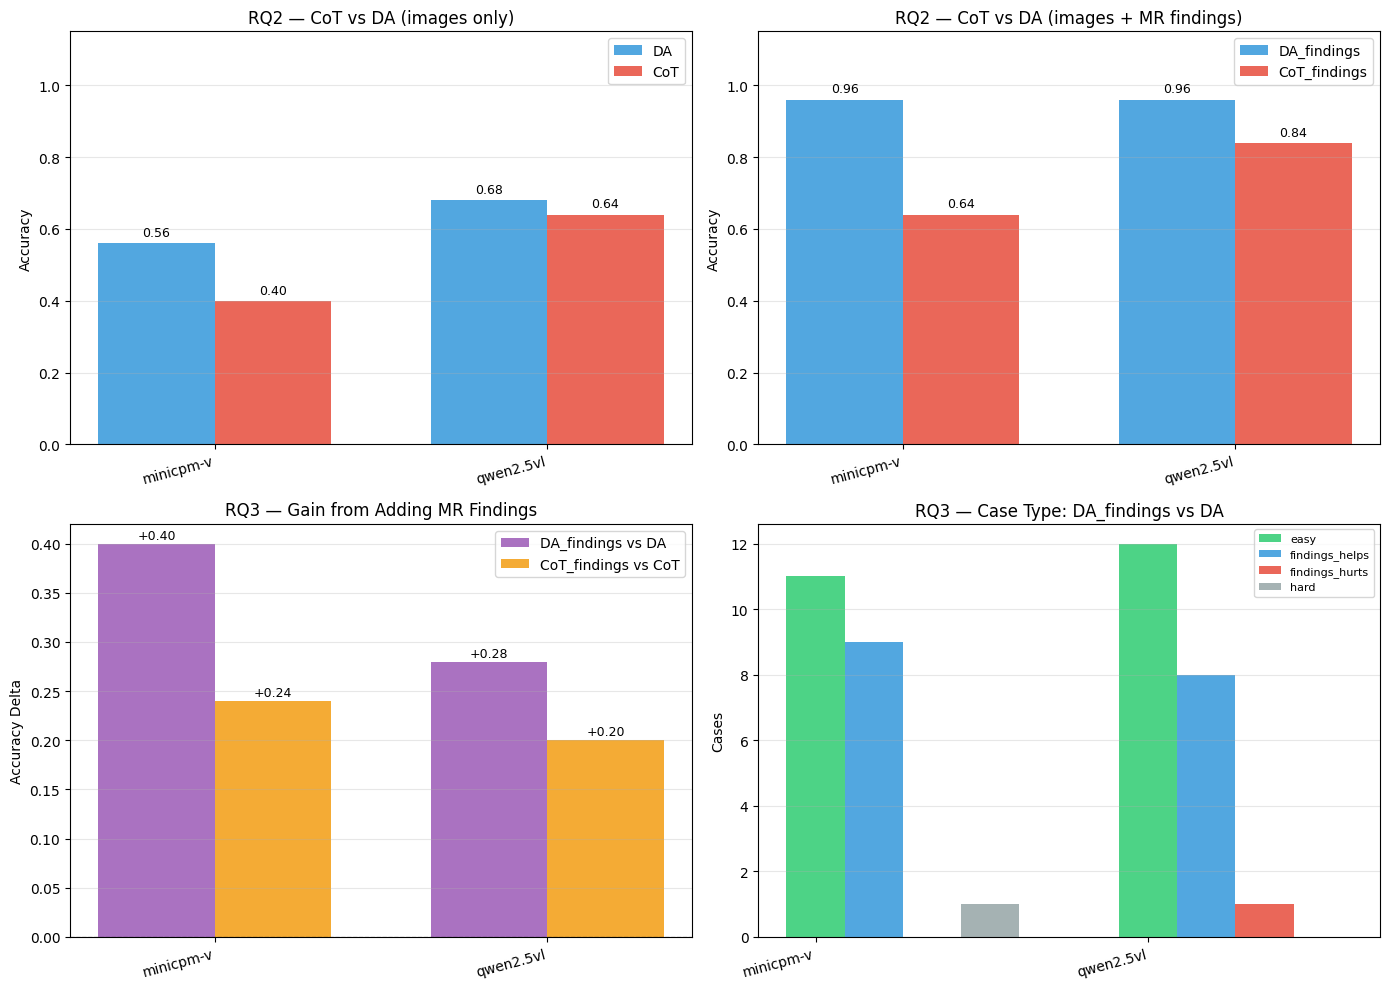

In [23]:
if df.empty:
    print("No results to plot yet — run the evaluation first")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    models_list = sorted(df["Model"].unique())
    x, w = range(len(models_list)), 0.35

    def get_acc(prompt):
        return [
            df[(df["Model"] == m) & (df["Prompt"] == prompt)]["Accuracy"].values[0]
            for m in models_list
            if ((df["Model"] == m) & (df["Prompt"] == prompt)).any()
        ]

    # ── Plot 1: RQ2 — CoT vs DA (images only) ────────────────────────────────
    da_acc  = get_acc("DA")
    cot_acc = get_acc("CoT")
    b1 = axes[0,0].bar([xi - w/2 for xi in x], da_acc,  w, label="DA",  color="#3498db", alpha=0.85)
    b2 = axes[0,0].bar([xi + w/2 for xi in x], cot_acc, w, label="CoT", color="#e74c3c", alpha=0.85)
    axes[0,0].set_xticks(list(x)); axes[0,0].set_xticklabels(models_list, rotation=15, ha="right")
    axes[0,0].set_ylabel("Accuracy"); axes[0,0].set_ylim(0, 1.15)
    axes[0,0].set_title("RQ2 — CoT vs DA (images only)"); axes[0,0].legend(); axes[0,0].grid(axis="y", alpha=0.3)
    for bar in list(b1)+list(b2):
        axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                       f"{bar.get_height():.2f}", ha="center", fontsize=9)

    # ── Plot 2: RQ2 — CoT_findings vs DA_findings (images + text) ────────────
    daf_acc  = get_acc("DA_findings")
    cotf_acc = get_acc("CoT_findings")
    b3 = axes[0,1].bar([xi - w/2 for xi in x], daf_acc,  w, label="DA_findings",  color="#3498db", alpha=0.85)
    b4 = axes[0,1].bar([xi + w/2 for xi in x], cotf_acc, w, label="CoT_findings", color="#e74c3c", alpha=0.85)
    axes[0,1].set_xticks(list(x)); axes[0,1].set_xticklabels(models_list, rotation=15, ha="right")
    axes[0,1].set_ylabel("Accuracy"); axes[0,1].set_ylim(0, 1.15)
    axes[0,1].set_title("RQ2 — CoT vs DA (images + MR findings)"); axes[0,1].legend(); axes[0,1].grid(axis="y", alpha=0.3)
    for bar in list(b3)+list(b4):
        axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                       f"{bar.get_height():.2f}", ha="center", fontsize=9)

    # ── Plot 3: RQ3 — findings vs no-findings (accuracy delta) ───────────────
    da_vals  = get_acc("DA")
    daf_vals = get_acc("DA_findings")
    cot_vals = get_acc("CoT")
    cotf_vals = get_acc("CoT_findings")
    delta_da  = [f - d for f, d in zip(daf_vals,  da_vals)]
    delta_cot = [f - c for f, c in zip(cotf_vals, cot_vals)]
    b5 = axes[1,0].bar([xi - w/2 for xi in x], delta_da,  w, label="DA_findings vs DA",   color="#9b59b6", alpha=0.85)
    b6 = axes[1,0].bar([xi + w/2 for xi in x], delta_cot, w, label="CoT_findings vs CoT", color="#f39c12", alpha=0.85)
    axes[1,0].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1,0].set_xticks(list(x)); axes[1,0].set_xticklabels(models_list, rotation=15, ha="right")
    axes[1,0].set_ylabel("Accuracy Delta"); axes[1,0].set_title("RQ3 — Gain from Adding MR Findings")
    axes[1,0].legend(); axes[1,0].grid(axis="y", alpha=0.3)
    for bar in list(b5)+list(b6):
        axes[1,0].text(bar.get_x()+bar.get_width()/2,
                       bar.get_height() + (0.005 if bar.get_height() >= 0 else -0.015),
                       f"{bar.get_height():+.2f}", ha="center", fontsize=9)

    # ── Plot 4: RQ3 — case type distribution ─────────────────────────────────
    if not df_cases.empty:
        rq3_df = df_cases[df_cases["comparison"] == "DA_findings_vs_DA"]
        case_types = ["easy", "findings_helps", "findings_hurts", "hard"]
        colors_rq3 = {"easy": "#2ecc71", "findings_helps": "#3498db",
                      "findings_hurts": "#e74c3c", "hard": "#95a5a6"}
        dist = rq3_df.groupby(["model", "case_type"]).size().unstack(fill_value=0)
        dist = dist.reindex(columns=case_types, fill_value=0)
        bar_x = range(len(dist.index))
        for j, ct in enumerate(case_types):
            axes[1,1].bar([xi + j*w/2 for xi in bar_x], dist[ct].values, w/2,
                          label=ct, color=colors_rq3[ct], alpha=0.85)
        axes[1,1].set_xticks(list(bar_x))
        axes[1,1].set_xticklabels([m.split(":")[0] for m in dist.index], rotation=15, ha="right")
        axes[1,1].set_ylabel("Cases"); axes[1,1].set_title("RQ3 — Case Type: DA_findings vs DA")
        axes[1,1].legend(fontsize=8); axes[1,1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(RESULTS_DIR, "vlm_plots.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved → {fig_path}")
    plt.show()

## Good models with only yes/no questions

In [ ]:
import json, os , random

In [ ]:

def load_and_report(path, label):
    with open(path, encoding="utf-8") as f:
        results = json.load(f)
    m = calculate_metrics(results)
    print(f"\n{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {m['accuracy']:.3f}")
    print(f"  F1        : {m['f1']:.3f}")
    print(f"  Precision : {m['precision']:.3f}")
    print(f"  Recall    : {m['recall']:.3f}")
    print(f"  Yes acc   : {m['tp']}/{m['tp']+m['fn']} ({m['tp']/(m['tp']+m['fn'])*100:.1f}%)" if (m['tp']+m['fn'])>0 else "")
    print(f"  No acc    : {m['tn']}/{m['tn']+m['fp']} ({m['tn']/(m['tn']+m['fp'])*100:.1f}%)" if (m['tn']+m['fp'])>0 else "")
    print(f"  UNCLEAR   : {m['unclear']}/{m['total']} ({m['unclear_pct']}%)")
    return m

DA  = load_and_report(
    "/content/drive/MyDrive/DS/KneeCoT/vlm_results/qwen2.5vl_DA_v3.json",
    "qwen2.5vl — Direct Answer (DA)"
)

CoT = load_and_report(
    "/content/drive/MyDrive/DS/KneeCoT/vlm_results/qwen2.5vl_CoT_v5.json",
    "qwen2.5vl — Chain of Thought (CoT)"
)


─────────────────────────────────────────────
  qwen2.5vl — Direct Answer (DA)
─────────────────────────────────────────────
  Accuracy  : 0.720
  F1        : 0.632
  Precision : 0.923
  Recall    : 0.480
  Yes acc   : 12/25 (48.0%)
  No acc    : 24/25 (96.0%)
  UNCLEAR   : 0/50 (0.0%)

─────────────────────────────────────────────
  qwen2.5vl — Chain of Thought (CoT)
─────────────────────────────────────────────
  Accuracy  : 0.600
  F1        : 0.565
  Precision : 0.619
  Recall    : 0.520
  Yes acc   : 13/25 (52.0%)
  No acc    : 17/25 (68.0%)
  UNCLEAR   : 0/50 (0.0%)


In [ ]:
def show_samples(path, label, n_correct=3, n_wrong=3):
    with open(path, encoding="utf-8") as f:
        results = json.load(f)

    correct = [r for r in results if r["prediction"] == r["ground_truth"]]
    wrong   = [r for r in results if r["prediction"] != r["ground_truth"]]

    random.seed(42)
    sample_correct = random.sample(correct, min(n_correct, len(correct)))
    sample_wrong   = random.sample(wrong,   min(n_wrong,   len(wrong)))

    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")

    print(f"\n✓ CORRECT PREDICTIONS ({len(correct)}/{len(results)})")
    print(f"{'─'*60}")
    for r in sample_correct:
        print(f"  Case    : {r['case_id']}")
        print(f"  Question: {r['question']}")
        print(f"  GT={r['ground_truth']}  Pred={r['prediction']}")
        print(f"  Response:\n{r.get('raw_response', 'N/A')}")
        print(f"{'─'*60}")

    print(f"\n✗ WRONG PREDICTIONS ({len(wrong)}/{len(results)})")
    print(f"{'─'*60}")
    for r in sample_wrong:
        print(f"  Case    : {r['case_id']}")
        print(f"  Question: {r['question']}")
        print(f"  GT={r['ground_truth']}  Pred={r['prediction']}")
        print(f"  Response:\n{r.get('raw_response', 'N/A')}")
        print(f"{'─'*60}")



show_samples(
    "/content/drive/MyDrive/DS/KneeCoT/vlm_results/qwen2.5vl_DA_v3.json",
    "qwen2.5vl — Direct Answer (DA)"
)

show_samples(
    "/content/drive/MyDrive/DS/KneeCoT/vlm_results/qwen2.5vl_CoT_v5.json",
    "qwen2.5vl — Chain of Thought (CoT)"
)


════════════════════════════════════════════════════════════
  qwen2.5vl — Direct Answer (DA)
════════════════════════════════════════════════════════════

✓ CORRECT PREDICTIONS (36/50)
────────────────────────────────────────────────────────────
  Case    : GJB0000171
  Question: 该患者本次膝关节 MRI 检查，是否存在骨皮质连续性中断？
  GT=No  Pred=No
  Response:
No.
────────────────────────────────────────────────────────────
  Case    : GJB0000117
  Question: 该患者本次膝关节 MRI 检查，关节周围软组织是否肿胀？
  GT=Yes  Pred=Yes
  Response:
Yes.
────────────────────────────────────────────────────────────
  Case    : GJB0000183
  Question: 该患者本次膝关节 MRI 检查，是否存在前交叉韧带损伤？
  GT=No  Pred=No
  Response:
No.
────────────────────────────────────────────────────────────

✗ WRONG PREDICTIONS (14/50)
────────────────────────────────────────────────────────────
  Case    : GJB0000047
  Question: 该患者本次膝关节 MRI 检查，前交叉韧带是否未见明确异常？
  GT=Yes  Pred=No
  Response:
No.
────────────────────────────────────────────────────────────
  Case    : GJB0000044


## VLM vs LLM
using samples of GJB0000001T and the same questions

In [25]:
import os, json
import pandas as pd

# Paths to the result files
LLM_RESULTS_PATH = "/content/inference_outputs.json"
VLM_COT_RESULTS_PATH = os.path.join(RESULTS_DIR, "qwen2.5vl_CoT_vision_inference.json")

if not os.path.exists(LLM_RESULTS_PATH):
    print(f"LLM results file not found at {LLM_RESULTS_PATH}")
elif not os.path.exists(VLM_COT_RESULTS_PATH):
    print(f"VLM CoT results file not found at {VLM_COT_RESULTS_PATH}")
else:
    # Load the LLM results
    with open(LLM_RESULTS_PATH, "r", encoding="utf-8") as f:
        llm_data = json.load(f)

    # The LLM file might be structured as a list of dicts with 'case_id', 'question', 'model_output', etc.
    # Create a lookup dictionary: (case_id, question) -> LLM output
    llm_lookup = {}
    for item in llm_data:
        case_id = item.get("case_id")
        question = item.get("question")
        # The output key might vary based on how inference_outputs.json was generated.
        # Assuming 'model_output' or 'prediction'
        output = item.get("model_output", item.get("prediction", ""))
        if case_id and question:
            llm_lookup[(case_id, question)] = output

    # Load the VLM CoT results
    with open(VLM_COT_RESULTS_PATH, "r", encoding="utf-8") as f:
        vlm_cot_data = json.load(f)

    comparison_rows = []
    match_count = 0

    # Iterate through VLM results and find matches in LLM results
    for vlm_item in vlm_cot_data:
        case_id = vlm_item.get("case_id")
        question = vlm_item.get("question")
        vlm_pred = vlm_item.get("prediction", "")
        gt_answer = vlm_item.get("ground_truth", "")

        llm_pred = llm_lookup.get((case_id, question))

        if llm_pred is not None:
            match_count += 1
            comparison_rows.append({
                "Case ID": case_id,
                "Question": question,
                "Ground Truth": gt_answer,
                "LLM Answer": llm_pred.strip(),
                "VLM CoT Answer": vlm_pred.strip(),
            })

    if match_count == 0:
        print("No overlapping questions found between LLM and VLM results based on Case ID and Question.")
    else:
        df_comp = pd.DataFrame(comparison_rows)

        print(f"={'='*80}")
        print(f" LLM vs VLM (CoT_vision) Comparison | {match_count} matched questions")
        print(f"={'='*80}")

        for i, row in df_comp.iterrows():
            print(f"\n{'─'*80}")
            print(f"Case: {row['Case ID']}")
            print(f"Q:    {row['Question']}")
            print(f"GT:   {row['Ground Truth'][:150]}..." if len(row['Ground Truth']) > 150 else f"GT:   {row['Ground Truth']}")
            print(f"LLM:  {row['LLM Answer'][:150]}..." if len(row['LLM Answer']) > 150 else f"LLM:  {row['LLM Answer']}")
            print(f"VLM:  {row['VLM CoT Answer'][:150]}..." if len(row['VLM CoT Answer']) > 150 else f"VLM:  {row['VLM CoT Answer']}")

        # Save comparison to CSV
        comp_csv_path = os.path.join(RESULTS_DIR, "llm_vs_vlm_cot_comparison.csv")
        df_comp.to_csv(comp_csv_path, index=False, encoding="utf-8-sig")
        print(f"\n Saved comparison to {comp_csv_path}")


 LLM vs VLM (CoT_vision) Comparison | 10 matched questions

────────────────────────────────────────────────────────────────────────────────
Case: GJB0000001T
Q:    根据国际通用的 Stoller 半月板损伤分级标准，该患者的半月板损伤属于几级？请说明推理依据。
GT:   属于 Stoller II 级。推理依据：半月板内可见条状 T2WI 高信号，但高信号未达半月板关节面边缘，符合 II 级损伤定义。
LLM:  (mock cot output)
【答案】这是一个用于测试管道的占位推理结论。
VLM:  根据国际通用的 Stoller 半月板损伤分级标准（一级：轻微撕裂；二级：部分撕裂；三级：完全撕裂），该患者的膝关节MR图像显示没有发现任何半月板损伤的证据。因此，该患者在当前状态下，其半月板损伤等级应为**0级**。

依据：
- 半月板形态完整。
- T2加权图像上信号正常。
- 前交叉韧带和后...

────────────────────────────────────────────────────────────────────────────────
Case: GJB0000001T
Q:    根据 MR 影像学表现，该患者的前交叉韧带损伤属于轻度、中度还是重度？请说明推理依据。
GT:   属于轻度损伤。推理依据：韧带增粗、边缘模糊、信号增高，但未见连续性中断或完全撕裂征象。
LLM:  (mock cot output)
【答案】这是一个用于测试管道的占位推理结论。
VLM:  根据MR影像学表现，该患者的前交叉韧带损伤属于重度。依据是前交叉韧带存在明显的断裂线和低信号强度，表明其损伤程度较重；而后交叉韧带形态正常，未见异常表现。

────────────────────────────────────────────────────────────────────────────────
Case: GJB0000001T
Q:    根据影像表现，该患者的膝关节软骨病变主要属于创伤性还是退行性改变？请说明依据。
GT:   主要属于退行性改变。推理依据：诸关节面软骨欠光